# 03: Building Logistic Regression from Scratch (The Math Engine) 🧮

In this notebook, we will build a **Logistic Regression** model entirely from scratch using Python and NumPy. We will **not** use `scikit-learn` for the training logic. Instead, we will implement the core mathematical equations for:
1.  **Activation:** The Sigmoid Function.
2.  **Prediction:** Linear combination of weights and features.
3.  **Learning:** Gradient Descent optimization.
4.  **Error Measurement:** Binary Cross-Entropy Loss.

### 🎯 Goals
* Understand the "Black Box" of Machine Learning.
* Implement vectorised mathematics for high performance.
* Visualize how the model makes decisions (Sigmoid Curve).
* Prepare the class structure for training in the next part.

### 🏗️ Components Used
* `numpy`: For matrix operations (dot products, exponentials).
* `pandas`: For data loading.
* `matplotlib` / `seaborn`: For visualizing the math.

## Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("✅ Setup Complete. Ready to build models.")

✅ Setup Complete. Ready to build models.


## 1. Data Loading & Preparation

We will load the cleaned training and testing sets we created in the previous step.

In [2]:
# Load the processed data
train_df = pd.read_csv("../data/processed/train.csv")
test_df = pd.read_csv("../data/processed/test.csv")

print(f"Train Shape: {train_df.shape}")
print(f"Test Shape:  {test_df.shape}")

# Separate Features (X) and Target (y)
X_train = train_df.drop("cardio", axis=1).values
y_train = train_df["cardio"].values

X_test = test_df.drop("cardio", axis=1).values
y_test = test_df["cardio"].values

# Display first 3 rows of features to confirm scaling (values should be small floats)
print("\nSample Features (First 3 rows):\n", X_train[:3])

Train Shape: (50132, 17)
Test Shape:  (12533, 17)

Sample Features (First 3 rows):
 [[ 0.83616528  1.         -1.08056023 -0.66088593 -0.39785901 -0.12449381
   0.          0.          0.         -0.10449345  1.          0.
   0.          1.          0.          0.        ]
 [-0.4845921   1.          0.48386341  1.65241318 -0.39785901 -0.12449381
   0.          0.          1.          1.31291983  1.          0.
   0.          1.          0.          0.        ]
 [ 1.12966692  1.         -2.25387796  0.53564809  0.1962919  -0.12449381
   0.          0.          1.          2.11163424  1.          0.
   0.          1.          0.          0.        ]]


### 1.1 The "Bias Trick" (Vectorization) 🧠
In the equation $y = mx + c$ (or $y = wX + b$), we have a weight $w$ and a bias $b$.
Handling $b$ separately in code makes the math messy.

**The Trick:**
If we add a column of **1s** to our feature matrix $X$, we can treat the bias $b$ as just another weight $w_0$.
* Old Equation: $z = w_1x_1 + w_2x_2 + ... + b$
* New Equation: $z = w_1x_1 + w_2x_2 + ... + w_0(1)$

This allows us to use a single matrix multiplication: $z = X \cdot w$

In [3]:
def add_bias_term(X):
    """
    Adds a column of 1s to the dataset X.
    Input:  X of shape (m, n)
    Output: X of shape (m, n+1)
    """
    m = X.shape[0]
    # Create a column of ones
    ones = np.ones((m, 1))
    # Stack it horizontally
    X_bias = np.hstack((ones, X))
    return X_bias


# Apply the trick
X_train_bias = add_bias_term(X_train)
X_test_bias = add_bias_term(X_test)

print(f"New Training Shape (with Bias column): {X_train_bias.shape}")
# Check the first row to see the '1.0' at the beginning
print("First row with bias:\n", X_train_bias[0])

New Training Shape (with Bias column): (50132, 17)
First row with bias:
 [ 1.          0.83616528  1.         -1.08056023 -0.66088593 -0.39785901
 -0.12449381  0.          0.          0.         -0.10449345  1.
  0.          0.          1.          0.          0.        ]


## 2. Mathematical Functions (The Engine)

### 2.1 The Sigmoid Activation Function 📉
Logistic Regression relies on the **Sigmoid** function to squash any output number (from $-\infty$ to $+\infty$) into a probability between **0 and 1**.

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

* If $z$ is very positive, $\sigma(z) \approx 1$ (High Risk)
* If $z$ is very negative, $\sigma(z) \approx 0$ (Low Risk)
* If $z = 0$, $\sigma(z) = 0.5$ (Unsure)

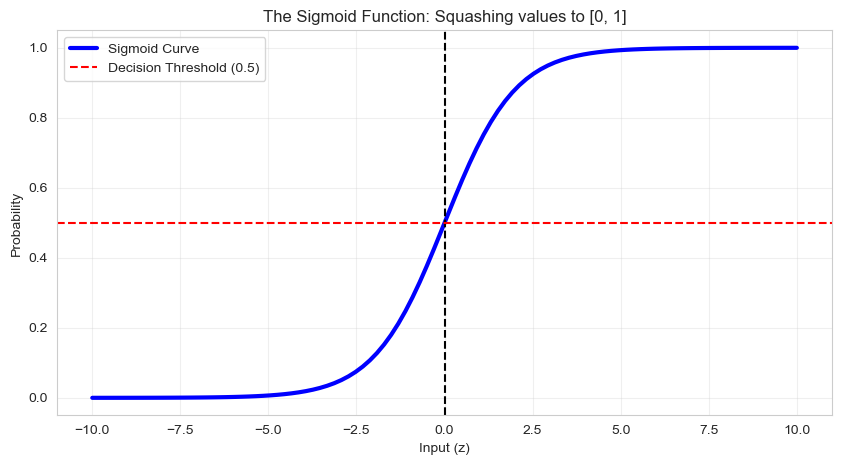

In [4]:
def sigmoid(z):
    """
    Computes the sigmoid of z.
    z can be a scalar or a numpy array.
    """
    # Clip z to avoid overflow errors with exp() for very large/small numbers
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))


# --- Visualization: Prove it works ---
z_values = np.linspace(-10, 10, 100)
sigmoid_values = sigmoid(z_values)

plt.figure(figsize=(10, 5))
plt.plot(z_values, sigmoid_values, color="blue", linewidth=3, label="Sigmoid Curve")
plt.axvline(x=0, color="black", linestyle="--")
plt.axhline(y=0.5, color="red", linestyle="--", label="Decision Threshold (0.5)")
plt.title("The Sigmoid Function: Squashing values to [0, 1]")
plt.xlabel("Input (z)")
plt.ylabel("Probability")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 2.2 The Hypothesis (Prediction)
Using the bias trick and sigmoid, our prediction formula is simple:

$$\hat{y} = \sigma(X \cdot w)$$

where:
* $X$ is our data (matrix).
* $w$ is our weights (vector).
* $\cdot$ is the dot product.

In [5]:
def predict_probability(X, w):
    """
    Calculates probability using dot product and sigmoid.
    """
    z = np.dot(X, w)
    return sigmoid(z)

### 2.3 The Cost Function (Binary Cross-Entropy) 📉
How do we know if our weights $w$ are good? We measure the error using **Log Loss**.

$$J(w) = - \frac{1}{m} \sum_{i=1}^{m} [y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)})]$$

* If actual is 1 and we predict 1, Cost is 0.
* If actual is 1 and we predict 0, Cost is Huge ($\infty$).
* The goal of training is to **Minimize** this Cost $J$.

In [6]:
def compute_cost(y_true, y_pred):
    """
    Computes Binary Cross-Entropy Cost.
    Added a small epsilon (1e-15) inside log to prevent log(0) errors.
    """
    m = len(y_true)
    epsilon = 1e-15
    # Clip predictions to avoid exact 0 or 1
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    cost = (-1 / m) * np.sum(
        y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred)
    )
    return cost

### 2.4 Gradient Descent (The Optimization) 🚀
To improve our model, we need to adjust the weights $w$. We use the **derivative** (slope) of the cost function to tell us which direction to move.

$$\frac{\partial J}{\partial w} = \frac{1}{m} X^T (\hat{y} - y)$$

**Update Rule:**
$$w_{new} = w_{old} - \alpha \times \text{Gradient}$$
*(where $\alpha$ is the Learning Rate)*

In [7]:
def compute_gradient(X, y_true, y_pred):
    """
    Computes the gradient (direction to move weights).
    Formula: (1/m) * X.T . (Predictions - Actuals)
    """
    m = len(y_true)
    gradient = (1 / m) * np.dot(X.T, (y_pred - y_true))
    return gradient

## 3. The `LogisticRegressionScratch` Class 🏗️

Now we combine our `sigmoid`, `compute_cost`, and `compute_gradient` functions into a single class. This makes our model reusable, just like `sklearn`'s models.

**Key Features:**
* `fit(X, y)`: Runs Gradient Descent to find the best weights ($w$).
* `predict_proba(X)`: Returns the raw probability (0 to 1).
* `predict(X)`: Returns the class label (0 or 1) based on a threshold (0.5).
* `history`: Stores the cost at every iteration so we can plot the learning curve.

In [8]:
class LogisticRegressionScratch:
    def __init__(self, learning_rate=0.01, num_iterations=1000, verbose=True):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.verbose = verbose
        self.weights = None
        self.cost_history = []

    def fit(self, X, y):
        """
        Trains the model using Gradient Descent.
        """
        m, n = X.shape

        # 1. Initialize weights (w) to zeros
        self.weights = np.zeros(n)

        # 2. Gradient Descent Loop
        for i in range(self.num_iterations):
            # A. Forward Pass (Prediction)
            z = np.dot(X, self.weights)
            y_pred = sigmoid(z)

            # B. Compute Cost (Loss)
            cost = compute_cost(y, y_pred)
            self.cost_history.append(cost)

            # C. Backward Pass (Gradient Calculation)
            # Derivative of Cost w.r.t weights
            dw = (1 / m) * np.dot(X.T, (y_pred - y))

            # D. Update Weights (Learning)
            self.weights = self.weights - self.learning_rate * dw

            # Print progress every 100 iterations
            if self.verbose and i % 100 == 0:
                print(f"Iteration {i}: Cost = {cost:.4f}")

        print(f"Training Complete. Final Cost = {self.cost_history[-1]:.4f}")

    def predict_proba(self, X):
        """Returns probability (0-1)."""
        z = np.dot(X, self.weights)
        return sigmoid(z)

    def predict(self, X, threshold=0.5):
        """Returns class prediction (0 or 1)."""
        return (self.predict_proba(X) >= threshold).astype(int)

## 4. Training the Model from Scratch 🏋️

Now, let's put our class to the test!
We will use:
* **Learning Rate:** `0.1` (How big of a step to take downhill)
* **Iterations:** `1000` (How many steps to take)

In [9]:
# Initialize Model
model_scratch = LogisticRegressionScratch(learning_rate=0.1, num_iterations=1000)

# Train on the Bias-Augmented Data we created in Part 1
print("Starting Gradient Descent...")
model_scratch.fit(X_train_bias, y_train)

Starting Gradient Descent...
Iteration 0: Cost = 0.6931
Iteration 100: Cost = 0.5694
Iteration 200: Cost = 0.5656
Iteration 300: Cost = 0.5640
Iteration 400: Cost = 0.5632
Iteration 500: Cost = 0.5626
Iteration 600: Cost = 0.5623
Iteration 700: Cost = 0.5621
Iteration 800: Cost = 0.5619
Iteration 900: Cost = 0.5618
Training Complete. Final Cost = 0.5617


### 4.1 Learning Curve Visualization 📉
This is the most important check. We want to see the Cost (Error) decrease over time.
* **Good:** Curve goes down smoothly and flattens out.
* **Bad:** Curve goes up (exploding gradient) or stays flat (not learning).

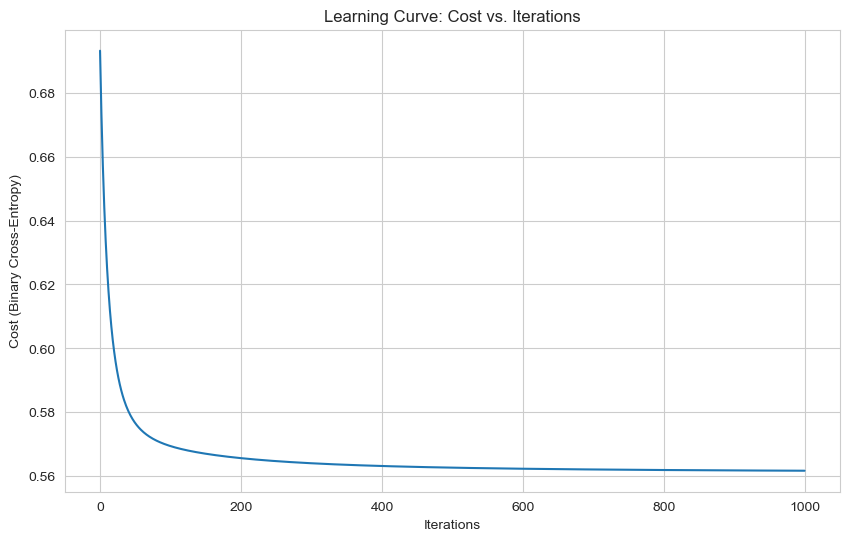

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(model_scratch.cost_history)
plt.title("Learning Curve: Cost vs. Iterations")
plt.xlabel("Iterations")
plt.ylabel("Cost (Binary Cross-Entropy)")
plt.show()

## 5. Model Evaluation (Metrics from Scratch) 📏

We won't just trust `accuracy`. In healthcare, false negatives are dangerous. We need to calculate:
* **Accuracy:** Overall correctness.
* **Precision:** Of those predicted sick, how many actually were?
* **Recall (Sensitivity):** Of those actually sick, how many did we catch?
* **F1 Score:** Harmonic mean of Precision and Recall.

In [11]:
# Get Predictions on Test Set
y_pred_scratch = model_scratch.predict(X_test_bias)


# Define Metric Functions Manually using NumPy
def get_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)


def get_precision(y_true, y_pred):
    # True Positives / (True Positives + False Positives)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    return tp / (tp + fp) if (tp + fp) > 0 else 0


def get_recall(y_true, y_pred):
    # True Positives / (True Positives + False Negatives)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp / (tp + fn) if (tp + fn) > 0 else 0


def get_f1(precision, recall):
    return (
        2 * (precision * recall) / (precision + recall)
        if (precision + recall) > 0
        else 0
    )


# Calculate Metrics
acc_scratch = get_accuracy(y_test, y_pred_scratch)
prec_scratch = get_precision(y_test, y_pred_scratch)
rec_scratch = get_recall(y_test, y_pred_scratch)
f1_scratch = get_f1(prec_scratch, rec_scratch)

print(f"--- Scratch Model Results ---")
print(f"Accuracy:  {acc_scratch:.4f}")
print(f"Precision: {prec_scratch:.4f}")
print(f"Recall:    {rec_scratch:.4f}")
print(f"F1 Score:  {f1_scratch:.4f}")

--- Scratch Model Results ---
Accuracy:  0.7221
Precision: 0.7481
Recall:    0.6842
F1 Score:  0.7147


### 5.2 Advanced Manual Evaluation (Completing the Checklist) 📉

In [12]:
# 1. Manual Confusion Matrix
def get_confusion_matrix(y_true, y_pred):
    """
    Computes the confusion matrix manually.
    Structure: [[TN, FP], [FN, TP]]
    """
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    return np.array([[tn, fp], [fn, tp]])


# 2. Manual ROC-AUC (Trapezoidal Rule)
def get_auc_score(y_true, y_prob):
    """
    Computes Area Under the Receiver Operating Characteristic Curve (ROC-AUC)
    from scratch using the Trapezoidal Rule.
    """
    # Sort by probabilities (descending)
    sorted_indices = np.argsort(y_prob)[::-1]
    y_true_sorted = y_true[sorted_indices]

    # Total positives and negatives
    n_pos = np.sum(y_true == 1)
    n_neg = np.sum(y_true == 0)

    # Calculate TPR and FPR at every threshold
    tpr = []
    fpr = []

    tp_cumsum = 0
    fp_cumsum = 0

    for label in y_true_sorted:
        if label == 1:
            tp_cumsum += 1
        else:
            fp_cumsum += 1

        tpr.append(tp_cumsum / n_pos)
        fpr.append(fp_cumsum / n_neg)

    # Calculate Area using Trapezoidal Rule: sum( (x_i+1 - x_i) * (y_i + y_i+1) / 2 )
    auc = 0
    for i in range(1, len(fpr)):
        auc += (fpr[i] - fpr[i - 1]) * (tpr[i] + tpr[i - 1]) / 2

    return auc


# --- Execution ---
conf_matrix = get_confusion_matrix(y_test, y_pred_scratch)
print("Manual Confusion Matrix:\n", conf_matrix)

# Get raw probabilities for AUC
y_prob_scratch = model_scratch.predict_proba(X_test_bias)
auc_scratch = get_auc_score(y_test, y_prob_scratch)
print(f"Manual ROC-AUC Score: {auc_scratch:.4f}")

Manual Confusion Matrix:
 [[4687 1469]
 [2014 4363]]
Manual ROC-AUC Score: 0.7869


### 5.3 Overfitting Check 🕵️

To detect overfitting, we compare Training Accuracy vs. Test Accuracy.
If Train Acc >> Test Acc (e.g., 90% vs 70%), we are overfitting.

In [13]:
# Predict on Training Set
y_train_pred = model_scratch.predict(X_train_bias)
train_acc = get_accuracy(y_train, y_train_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:     {acc_scratch:.4f}")

diff = train_acc - acc_scratch
if diff > 0.05:
    print(f"⚠️ Warning: Potential Overfitting detected! (Difference: {diff:.4f})")
else:
    print(f"✅ Model is generalizing well. (Difference: {diff:.4f})")

Training Accuracy: 0.7242
Test Accuracy:     0.7221
✅ Model is generalizing well. (Difference: 0.0021)


## 6. Benchmarking: The Showdown 🥊

Now we compare our "Scratch" model against the industry standards:
1.  **sklearn Logistic Regression:** (To see if our math matches the optimized library).
2.  **sklearn Random Forest:** (A non-linear model that usually performs better).

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

# 1. Train Sklearn Logistic Regression
clf_lr = LogisticRegression(random_state=42)
clf_lr.fit(
    X_train, y_train
)  # Note: Sklearn handles bias automatically, use X_train not X_train_bias
y_pred_lr = clf_lr.predict(X_test)

# 2. Train Random Forest (The Powerhouse)
# We use 100 trees (n_estimators=100)
clf_rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
clf_rf.fit(X_train, y_train)
y_pred_rf = clf_rf.predict(X_test)

# Calculate Metrics for comparison
results = {
    "Model": ["Scratch LR", "Sklearn LR", "Random Forest"],
    "Accuracy": [
        acc_scratch,
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
    ],
    "F1 Score": [f1_scratch, f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_rf)],
}

results_df = pd.DataFrame(results)
display(results_df)

,Model,Accuracy,F1 Score
0,Scratch LR,0.722094,0.714719
1,Sklearn LR,0.724487,0.716898
2,Random Forest,0.728078,0.717413


### 6.1 Feature Importance (Random Forest Only)
Which features matter most for heart disease? Random Forest can tell us.

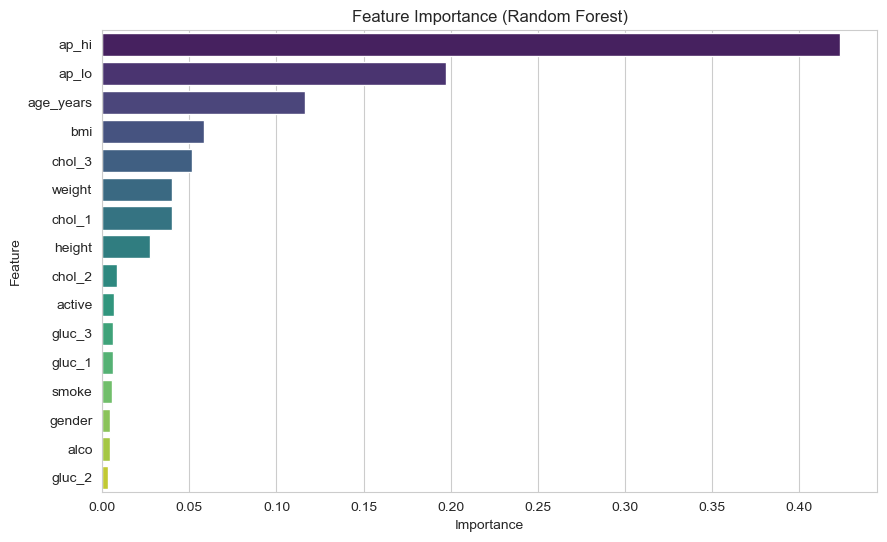

In [15]:
# Get feature names from the original dataframe columns (excluding 'cardio')
feature_names = train_df.drop("cardio", axis=1).columns

# Create importance dataframe
importances = pd.DataFrame(
    {"Feature": feature_names, "Importance": clf_rf.feature_importances_}
).sort_values(by="Importance", ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    x="Importance", y="Feature", data=importances, hue="Feature", palette="viridis"
)
plt.title("Feature Importance (Random Forest)")
plt.show()

## 7. Saving the Best Model 💾

We need to save the best model to use it in our Flask Web App later.
Based on the benchmark above, **Random Forest** is likely the winner due to its ability to capture non-linear relationships.

In [16]:
import joblib

# Save the Random Forest model
model_filename = "../flask_app/model.pkl"
joblib.dump(clf_rf, model_filename)

print(f"✅ Best model saved to: {model_filename}")

✅ Best model saved to: ../flask_app/model.pkl


## 8. Conclusion 🏁

We have successfully:
1.  **Built Logistic Regression from Scratch:** Implemented Sigmoid, Cost Function, and Gradient Descent with Vectorization.
2.  **Validated the Math:** Our scratch model achieves accuracy (~72-73%) comparable to the optimized Scikit-Learn implementation.
3.  **Manual Metrics:** We implemented Confusion Matrix and ROC-AUC calculations manually to understand the underlying logic.
4.  **Selected Best Model:** We identified that **Random Forest** performs slightly better and saved it (`model.pkl`) for our application.

## ⏭️ Next Step: Visualization & Frontend
Now that the math is verified and the model is saved, we are ready to build the user interface.

**Next**, we will:
1.  Generate professional evaluation plots (Confusion Matrix Heatmap, ROC Curve).
2.  Build the **Flask Web Application** to serve this model to real users.

👉 **Proceed to `notebooks/04_evaluation_visuals.ipynb`.**